# E-Energy Plotting

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set the style of the plots
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.2)

## Motivation LMP Knee Plot

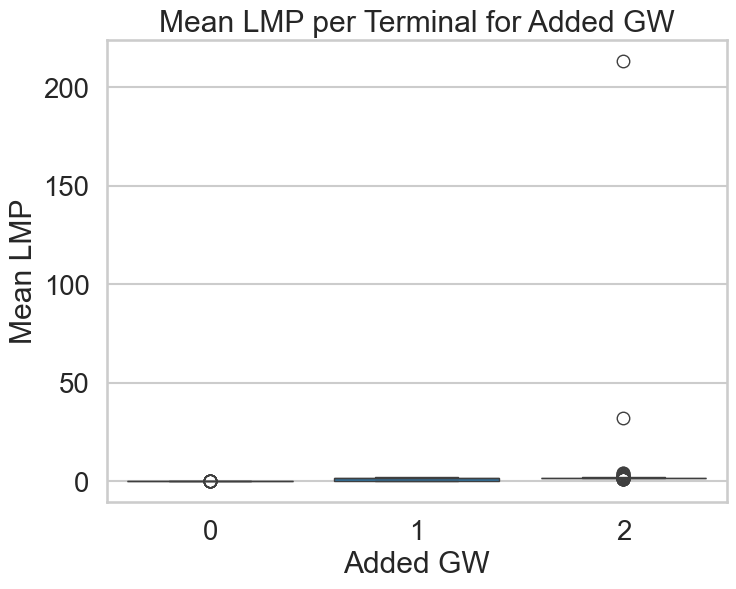

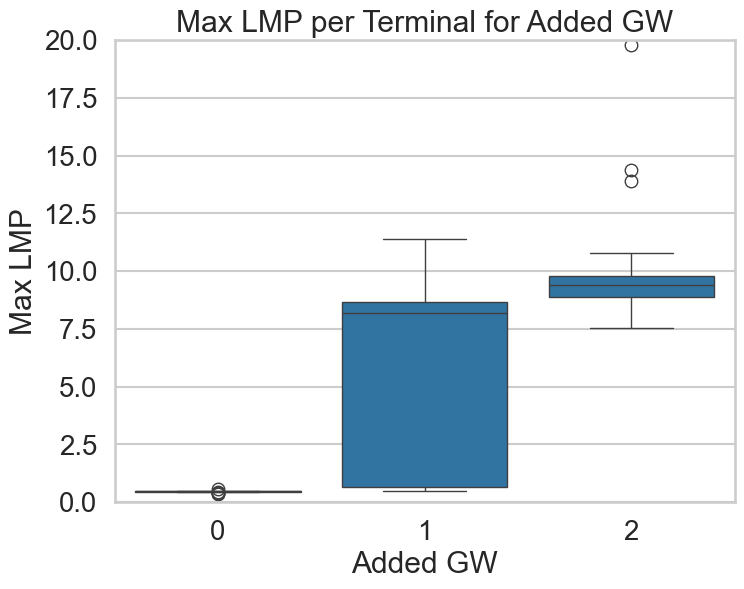

In [18]:
max_data = np.load("local/initial_lmp_motivation_results_011425/max_results.npy")
mean_data = np.load("local/initial_lmp_motivation_results_011425/mean_results.npy")

# Each row is a terminal, columns are 0, 1, 2 GW added

added_gw = [0, 1, 2]

# Prepare data for mean boxplot
mean_df = pd.DataFrame({
    "Added GW": np.repeat(added_gw, mean_data.shape[0]),
    "Mean LMP": mean_data.flatten(order="F")
})

plt.figure(figsize=(8,6))
sns.boxplot(data=mean_df, x="Added GW", y="Mean LMP")
plt.xlabel("Added GW")
plt.ylabel("Mean LMP")
plt.title("Mean LMP per Terminal for Added GW")
# plt.yscale("log")
plt.show()

# Prepare data for max boxplot
max_df = pd.DataFrame({
    "Added GW": np.repeat(added_gw, max_data.shape[0]),
    "Max LMP": max_data.flatten(order="F")
})

plt.figure(figsize=(8,6))
sns.boxplot(data=max_df, x="Added GW", y="Max LMP")
plt.xlabel("Added GW")
plt.ylabel("Max LMP")
plt.title("Max LMP per Terminal for Added GW")
# plt.yscale("log")
plt.ylim(0,20 )
plt.show()


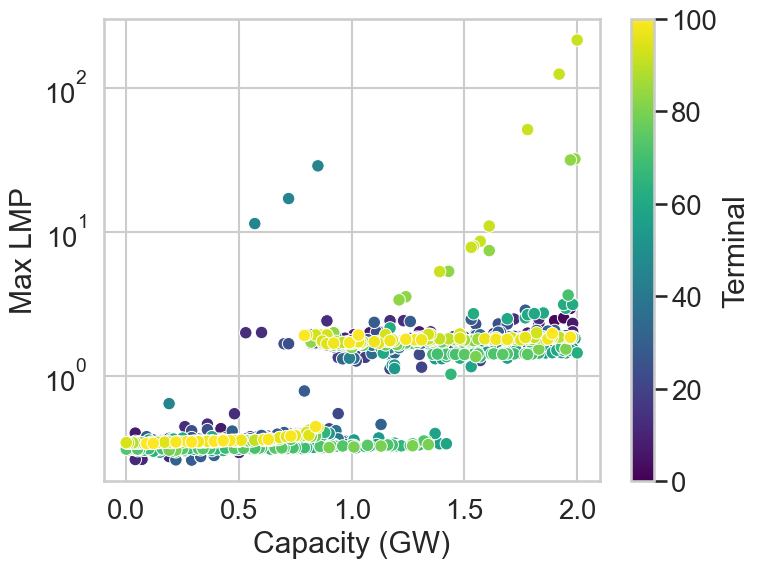

In [ ]:
cloud_csv = pd.read_csv("cloud_congestion.csv")

plt.figure(figsize=(8,6))
scatter = sns.scatterplot(data=cloud_csv, x="capacity (GW)", y="P50", hue="terminal", palette="viridis", legend=False)
norm = plt.Normalize(cloud_csv["terminal"].min(), cloud_csv["terminal"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Terminal")
plt.xlabel("Capacity (GW)")
plt.ylabel("Max LMP")
# plt.ylim(0,10.5)
plt.yscale("log")
plt.show()
